In [2]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Literal

In [3]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [23]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation': equation}

def calculate_discriminant(state: QuadState):

    discriminant = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminant': discriminant}

def real_roots(state: QuadState): # discriminant > 0

    root1 = - state["b"] + state["discriminant"]**0.5 / (2 * state["a"])
    root2 = - state["b"] - state["discriminant"]**0.5 / (2 * state["a"])

    result = f" The roots are {root1} and {root2}"

    return {'result': result}

def repeated_roots(state: QuadState):  # discriminant == 0

    root = - state["b"] / (2 * state["a"])

    result = f"The only root is {root}"

    return {'result': result}

def no_real_roots(state: QuadState): # discriminant < 0

    result = f"No real roots exist"

    return {'result': result}

def check_condition(state: QuadState) -> Literal["no_real_roots", "repeated_roots", "real_roots"]:

    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

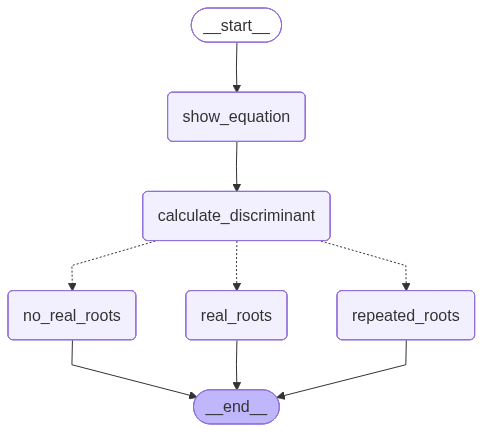

In [24]:
# create graph

graph = StateGraph(QuadState)

# add nodes to the graph

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('no_real_roots', no_real_roots)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)

# add edges to the graph

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

# compile the graph

workflow = graph.compile()

workflow

In [27]:
# execute graph

initial_state = { 
    'a': 2,
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'The only root is -1.0'}